In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nani123456789/social-network-ads/Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

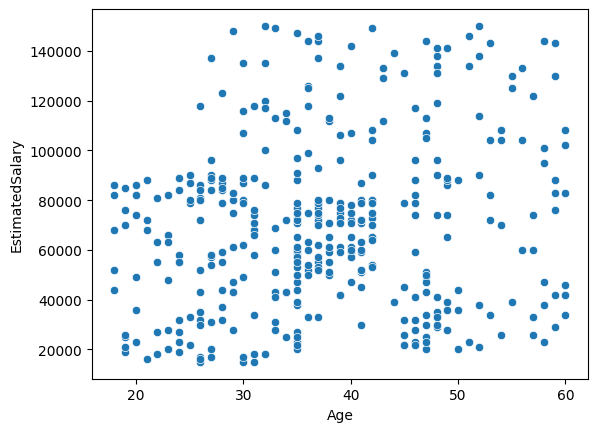

In [6]:
sns.scatterplot(
    x=df.iloc[:, 0],
    y=df.iloc[:, 1]
)

In [7]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense 

In [10]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1784624461.976120      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784624461.979221      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
 history  = model.fit(X_train, y_train, validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2500 - loss: 1479.4725

I0000 00:00:1784624464.683598      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5469 - loss: 474.4104 - val_accuracy: 0.4000 - val_loss: 107.8980
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4719 - loss: 198.8088 - val_accuracy: 0.6000 - val_loss: 102.0439
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5281 - loss: 59.0257 - val_accuracy: 0.4000 - val_loss: 95.3517
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4281 - loss: 75.7863 - val_accuracy: 0.6000 - val_loss: 79.0261
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5656 - loss: 83.6562 - val_accuracy: 0.6000 - val_loss: 46.9166
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5469 - loss: 52.3230 - val_accuracy: 0.6000 - val_loss: 9.5375
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5281 - loss: 41.7571 - val_accuracy: 0.6000 - val_loss: 9.1787
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5312 - loss: 37.4954 - val_accurac

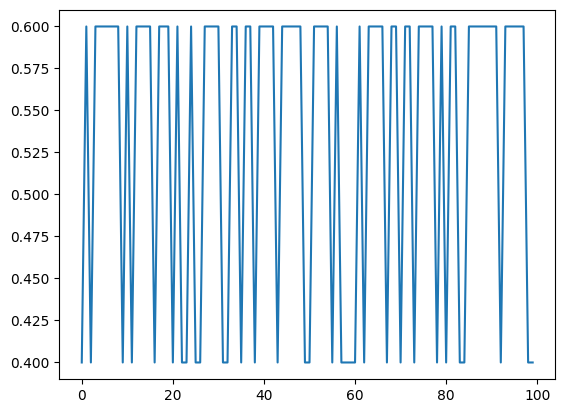

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'])

# Applying Scaling 


In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
X_test_scaled

array([[-0.84826272,  0.40218125],
       [-1.62050759, -1.57325199],
       [-0.07601785, -0.48234109],
       [-0.84826272,  0.16630863],
       [ 1.56500249,  0.01888824],
       [ 0.88928823, -1.45531567],
       [-1.42744637,  0.37269718],
       [-0.94479333, -1.10150673],
       [ 0.21357397, -0.27595254],
       [-0.17254846,  1.66999662],
       [-1.33091576, -1.36686344],
       [-1.52397698, -1.24892713],
       [-0.5586709 ,  1.40463991],
       [ 0.69622701,  0.28424494],
       [-0.26907907, -0.30543662],
       [-0.46214029, -0.77718187],
       [-1.8135688 ,  0.01888824],
       [ 2.14418614, -0.80666595],
       [ 1.46847188,  0.07785639],
       [-1.13785454, -0.77718187],
       [-0.07601785,  0.25476086],
       [ 0.69622701, -0.71821372],
       [-0.75173211, -0.21698439],
       [-0.17254846, -1.07202266],
       [-1.23438515,  0.31372902],
       [ 0.69622701, -1.10150673],
       [ 0.69622701, -1.39634752],
       [ 0.21357397, -0.36440478],
       [ 0.5996964 ,

<Axes: >

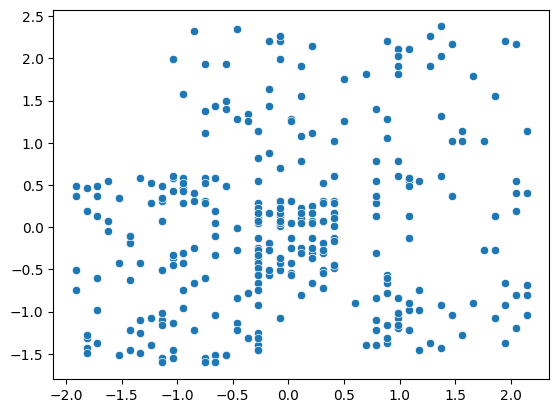

In [17]:
sns.scatterplot(x=X_train_scaled[:,0],y=X_train_scaled[:,1])

In [18]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

history  = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled,y_test),epochs=200)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5469 - loss: 0.6728 - val_accuracy: 0.8000 - val_loss: 0.6206
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7937 - loss: 0.6108 - val_accuracy: 0.8375 - val_loss: 0.5654
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8281 - loss: 0.5629 - val_accuracy: 0.8625 - val_loss: 0.5177
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8562 - loss: 0.5211 - val_accuracy: 0.8625 - val_loss: 0.4778
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8625 - loss: 0.4848 - val_accuracy: 0.8375 - val_loss: 0.4460
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8719 - loss: 0.4545 - val_accuracy: 0.8250 - val_loss: 0.4192
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8781 - loss: 0.4284 - val_accuracy: 0.8375 - val_loss: 0.3958
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8844 - loss: 0.4056 - val_accuracy: 0.8375 - val_l

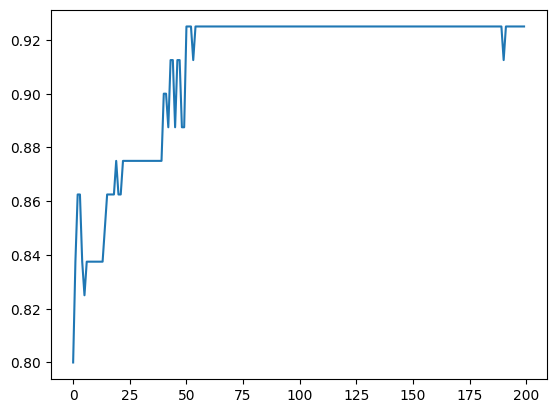

In [19]:
plt.plot(history.history['val_accuracy'])